In [3]:
using Plots
using LinearAlgebra

In [4]:
# Physical parameters
c = 3e8                  # Speed of light (m/s)
f = 433e6                # RF frequency (Hz)
λ = c / f                # Wavelength (m)

println("Frequency = ", f / 1e6, " MHz")
println("Wavelength = ", λ, " m")

Frequency = 433.0 MHz
Wavelength = 0.6928406466512702 m


In [5]:
# Number of outer antennas
N = 6

# Angular position of each antenna
phi = (0:N-1) .* (2 * π / N)

# Convert to degrees so it is easier to read
phi_deg = rad2deg.(phi)

println("Antenna angles = ", phi_deg)

Antenna angles = [0.0, 59.99999999999999, 119.99999999999999, 180.0, 239.99999999999997, 299.99999999999994]


In [6]:
# Desired spacing between neighbouring antennas
d = 0.4 * λ

# Radius of the circular array
# Keeping neighbour spacing fixed means the array radius changes when N changes
R = d / (2 * sin(π / N))

println("Neighbour spacing = ", d, " m")
println("Array radius = ", R, " m")

Neighbour spacing = 0.2771362586605081 m
Array radius = 0.2771362586605082 m


In [7]:
# Antenna coordinates
x = R .* cos.(phi)
y = R .* sin.(phi)

for i = 1:N
    println("Antenna ", i, ": x = ", x[i], " m, y = ", y[i], " m")
end

Antenna 1: x = 0.2771362586605082 m, y = 0.0 m
Antenna 2: x = 0.13856812933025411 m, y = 0.2400070403097752 m
Antenna 3: x = -0.13856812933025403 m, y = 0.24000704030977524 m
Antenna 4: x = -0.2771362586605082 m, y = 3.393940320962643e-17 m
Antenna 5: x = -0.1385681293302542 m, y = -0.24000704030977518 m
Antenna 6: x = 0.1385681293302539 m, y = -0.24000704030977532 m


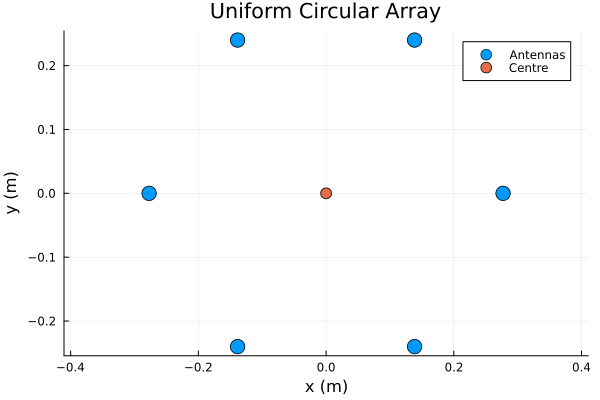

In [8]:
scatter(x, y,
    xlabel = "x (m)",
    ylabel = "y (m)",
    label = "Antennas",
    markersize = 8,
    aspect_ratio = :equal,
    title = "Uniform Circular Array")

scatter!([0], [0],
    label = "Centre",
    markersize = 6)

In [9]:
# Incoming signal direction
phi0_deg = 30
theta0_deg = 90

phi0 = deg2rad(phi0_deg)
theta0 = deg2rad(theta0_deg)

# Path difference relative to the centre
OD = R .* cos.(phi0 .- phi) .* sin(theta0)

for i = 1:N
    println("Antenna ", i, ": OD = ", OD[i], " m")
end

Antenna 1: OD = 0.24000704030977524 m
Antenna 2: OD = 0.24000704030977524 m
Antenna 3: OD = 1.6969701604813214e-17 m
Antenna 4: OD = -0.24000704030977524 m
Antenna 5: OD = -0.24000704030977527 m
Antenna 6: OD = -2.9705554907313493e-16 m


In [10]:
# Arrival-time difference relative to the centre
delta_t = -OD ./ c

for i = 1:N
    println("Antenna ", i, ": Δt = ", delta_t[i], " s")
end

Antenna 1: Δt = -8.000234676992508e-10 s
Antenna 2: Δt = -8.000234676992508e-10 s
Antenna 3: Δt = -5.656567201604405e-26 s
Antenna 4: Δt = 8.000234676992508e-10 s
Antenna 5: Δt = 8.000234676992508e-10 s
Antenna 6: Δt = 9.901851635771165e-25 s


In [11]:
# Phase relative to the centre
phase = -2 * π * f .* delta_t
phase_deg = rad2deg.(phase)

for i = 1:N
    println("Antenna ", i, ": phase = ", phase_deg[i], " degrees")
end

Antenna 1: phase = 124.70765814495923 degrees
Antenna 2: phase = 124.70765814495923 degrees
Antenna 3: phase = 8.817456953860946e-15 degrees
Antenna 4: phase = -124.70765814495923 degrees
Antenna 5: phase = -124.70765814495923 degrees
Antenna 6: phase = -1.543500632984009e-13 degrees


In [12]:
# Steering vector of the outer antennas
a = exp.(im .* phase)

println("Steering vector:")
for i = 1:N
    println("Antenna ", i, ": ", a[i])
end

Steering vector:
Antenna 1: -0.5693894059898202 + 0.8220679438748112im
Antenna 2: -0.5693894059898202 + 0.8220679438748112im
Antenna 3: 1.0 + 1.5389365549774326e-16im
Antenna 4: -0.5693894059898202 - 0.8220679438748112im
Antenna 5: -0.5693894059898202 - 0.8220679438748112im
Antenna 6: 1.0 - 2.6939168052187547e-15im


In [26]:
# Angles to test
phi_test_deg = 0:0.1:(360 - 0.1)
score = zeros(length(phi_test_deg))

for k = 1:length(phi_test_deg)

    phi_test = deg2rad(phi_test_deg[k])

    # Expected path difference for this test angle
    OD_test = R .* cos.(phi_test .- phi) .* sin(theta0)

    # Expected phase pattern
    phase_test = (2 * π / λ) .* OD_test

    # Expected steering vector
    a_test = exp.(im .* phase_test)

    # Compare with the received phase pattern
    score[k] = abs(sum(conj.(a_test) .* a))
end

# Find best matching direction
phi_est = phi_test_deg[argmax(score)]

println("True direction      = ", phi0_deg, " degrees")
println("Estimated direction = ", phi_est, " degrees")

True direction      = 30 degrees
Estimated direction = 30.0 degrees


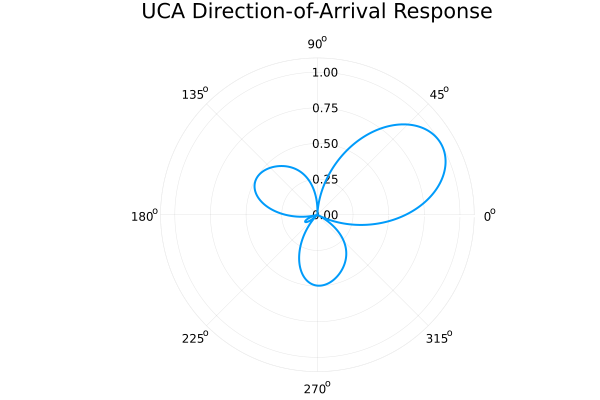

In [27]:
score = score ./ maximum(score)

plot(deg2rad.(phi_test_deg), score,
    proj = :polar,
    label = false,
    linewidth = 2,
    title = "UCA Direction-of-Arrival Response")

In [30]:
##
# Detection of the direction of the main lobe and the second strongest lobe 
##
main_index = argmax(score)

# Find local peaks, including across the 0°/360° boundary
is_peak = (score.>circshift(score, 1)) .& (score.>circshift(score, -1))

peak_indices = findall(is_peak)

# Remove the main peak and find the strongest remaining peak
side_indices = filter(i -> i  != main_index, peak_indices)
side_index = side_indices[argmax(score[side_indices])]

main_angle = phi_test_deg[main_index]
side_angle = phi_test_deg[side_index]

# Main peak relative to strongest incorrect peak
SLL_dB = 20 * log10(score[main_index] / score[side_index])

println("Main peak angle      = ", main_angle, " degrees")
println("Strongest other peak = ", side_angle, " degrees")
println("Sidelobe separation  = ", SLL_dB, " dB")

Main peak angle      = 30.0 degrees
Strongest other peak = 271.8 degrees
Sidelobe separation  = 6.063770738245814 dB


In [31]:
half_power = 1 / sqrt(2)

# Shift the main peak to the middle to avoid the 0°/360° boundary
centre = div(length(score), 2) + 1
score_shifted = circshift(score, centre - main_index)

left = centre
while left > 1 && score_shifted[left] >= half_power
    left -= 1
end

right = centre
while right < length(score) && score_shifted[right] >= half_power
    right += 1
end

HPBW = (right - left - 2) * step(phi_test_deg)

println("HPBW = ", HPBW, " degrees")

HPBW = 51.6 degrees
